Question 1 Projection of a 3D Point

In [7]:
import numpy as np

# given values from the homework
f = 480.0
cx, cy = 320.0, 270.0
K = np.array([
    [f, 0.0, cx],
    [0.0, f, cy],
    [0.0, 0.0, 1.0],
])

# R is world-to-camera, t is camera position in world frame
R_G_C = np.array([
    [0.5363, -0.8440, 0.0],
    [0.8440,  0.5363, 0.0],
    [0.0,     0.0,    1.0],
])
t_C_G = np.array([[-451.2459], [257.0322], [400.0]])

# the 3D point and its measured image location
X_G = np.array([[350.0], [-250.0], [-35.0]])
z_meas = np.array([241.5, 169.0])

# build P = K [R | t], need to convert t to camera frame first
t_G_C = -R_G_C @ t_C_G
P = K @ np.hstack((R_G_C, t_G_C))

# project the point
X_h = np.vstack((X_G, [[1.0]]))
x_h = P @ X_h
z_proj = x_h[:2, 0] / x_h[2, 0]
depth = x_h[2, 0]

# reprojection error
err_px = np.linalg.norm(z_proj - z_meas)

print("Camera projection matrix P:")
print(np.round(P, 4))
print(f"\nProjected pixel: u = {z_proj[0]:.4f}, v = {z_proj[1]:.4f}")
print(f"Camera-frame depth: Z = {depth:.4f}")
print(f"Reprojection error: {err_px:.4f} px")
if depth < 0:
    print("The point has negative camera-frame depth; it is behind the camera.")


Camera projection matrix P:
[[ 2.57424000e+02 -4.05120000e+02  3.20000000e+02  9.22904094e+04]
 [ 4.05120000e+02  2.57424000e+02  2.70000000e+02  8.64248200e+03]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00 -4.00000000e+02]]

Projected pixel: u = -626.3651, v = -176.1574
Camera-frame depth: Z = -435.0000
Reprojection error: 933.9826 px
The point has negative camera-frame depth; it is behind the camera.


Question 2 Calibrate Camera Using ChArUco Pattern

OpenCV version: 4.13.0
Found 29 calibration images.
Valid calibration views: 28
RMS reprojection error: 1.6022 px
Intrinsic matrix K:
[[3.41128e+03 0.00000e+00 1.42794e+03]
 [0.00000e+00 3.34367e+03 1.23631e+03]
 [0.00000e+00 0.00000e+00 1.00000e+00]]
Distortion coefficients:
[-5.59450e-01  2.94151e+00 -1.00000e-04 -1.36900e-02 -6.39577e+00]
Saved calibration figures:
  hw3_report_figures\calibration_corners_01.png
  hw3_report_figures\calibration_corners_02.png
  hw3_report_figures\calibration_corners_03.png
  hw3_report_figures\calibration_corners_04.png
  hw3_report_figures\calibration_corners_05.png
  hw3_report_figures\calibration_corners_06.png


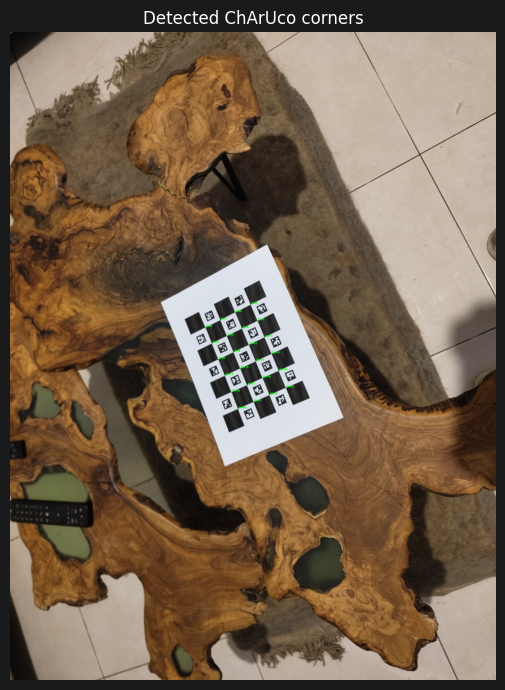

In [8]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

CALIBRATION_DIR = Path("calibration_images")
OUTPUT_DIR = Path("hw3_report_figures")
OUTPUT_DIR.mkdir(exist_ok=True)

# board dimensions - 5x7 squares, 4cm each, markers are 2cm
CHARUCO_SQUARES_X = 5
CHARUCO_SQUARES_Y = 7
SQUARE_METERS = 0.040
MARKER_METERS = 0.020

def run_charuco_calibration(data_directory=CALIBRATION_DIR, output_dir=OUTPUT_DIR, max_debug_images=6):
    print(f"OpenCV version: {cv2.__version__}")

    dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_5X5_100)
    board = cv2.aruco.CharucoBoard(
        (CHARUCO_SQUARES_X, CHARUCO_SQUARES_Y),
        SQUARE_METERS,
        MARKER_METERS,
        dictionary,
    )

    # some printed boards need this
    if hasattr(board, "setLegacyPattern"):
        board.setLegacyPattern(True)

    # handle both old and new OpenCV API
    modern_api = hasattr(cv2.aruco, "CharucoDetector")
    detector = cv2.aruco.CharucoDetector(board) if modern_api else None
    detector_params = None if modern_api else cv2.aruco.DetectorParameters_create()

    image_files = sorted([
        p for p in Path(data_directory).iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ]) if Path(data_directory).exists() else []

    if not image_files:
        image_files = sorted([
            p for p in Path(".").iterdir()
            if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
        ])

    if not image_files:
        raise FileNotFoundError("No calibration images were found.")

    all_corners, all_ids = [], []
    frame_size = None
    debug_paths = []

    print(f"Found {len(image_files)} calibration images.")

    for image_path in image_files:
        frame_bgr = cv2.imread(str(image_path))
        if frame_bgr is None:
            continue

        gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
        frame_size = gray.shape[::-1] if frame_size is None else frame_size

        if modern_api:
            charuco_corners, charuco_ids, marker_corners, marker_ids = detector.detectBoard(gray)
        else:
            marker_corners, marker_ids, _ = cv2.aruco.detectMarkers(
                gray, dictionary, parameters=detector_params
            )
            if marker_ids is None or len(marker_ids) == 0:
                charuco_corners, charuco_ids = None, None
            else:
                _, charuco_corners, charuco_ids = cv2.aruco.interpolateCornersCharuco(
                    marker_corners, marker_ids, gray, board
                )

        # skip images where we couldn't find enough corners
        if charuco_corners is None or charuco_ids is None or len(charuco_corners) <= 3:
            continue

        all_corners.append(charuco_corners)
        all_ids.append(charuco_ids)

        # save a few annotated images to show the detected corners
        if len(debug_paths) < max_debug_images:
            annotated = frame_bgr.copy()
            cv2.aruco.drawDetectedCornersCharuco(
                annotated, charuco_corners, charuco_ids, (0, 255, 0)
            )
            out_path = output_dir / f"calibration_corners_{len(debug_paths)+1:02d}.png"
            cv2.imwrite(str(out_path), annotated)
            debug_paths.append(out_path)

    if not all_corners:
        raise RuntimeError("ChArUco corners were not detected in any calibration image.")

    try:
        rms, K_matrix, dist_coeffs, rvecs, tvecs = cv2.aruco.calibrateCameraCharuco(
            charucoCorners=all_corners,
            charucoIds=all_ids,
            board=board,
            imageSize=frame_size,
            cameraMatrix=None,
            distCoeffs=None,
        )
    except AttributeError:
        # newer OpenCV removed calibrateCameraCharuco, use the generic one
        obj_points, img_points = [], []
        for corners, ids in zip(all_corners, all_ids):
            objp, imgp = board.matchImagePoints(corners, ids)
            if objp is not None and len(objp) > 3:
                obj_points.append(objp)
                img_points.append(imgp)

        rms, K_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
            obj_points, img_points, frame_size, None, None
        )

    print(f"Valid calibration views: {len(all_corners)}")
    print(f"RMS reprojection error: {rms:.4f} px")
    print("Intrinsic matrix K:")
    print(np.round(K_matrix, 2))
    print("Distortion coefficients:")
    print(np.round(dist_coeffs.ravel(), 5))
    print("Saved calibration figures:")
    for p in debug_paths:
        print(f"  {p}")

    if debug_paths:
        preview = cv2.cvtColor(cv2.imread(str(debug_paths[0])), cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(9, 7))
        plt.imshow(preview)
        plt.title("Detected ChArUco corners")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    return K_matrix, dist_coeffs, rms, debug_paths

K_calib, dist_coeffs, rms_px, calibration_figures = run_charuco_calibration()


Question 3
Image Feature Extraction and Matching

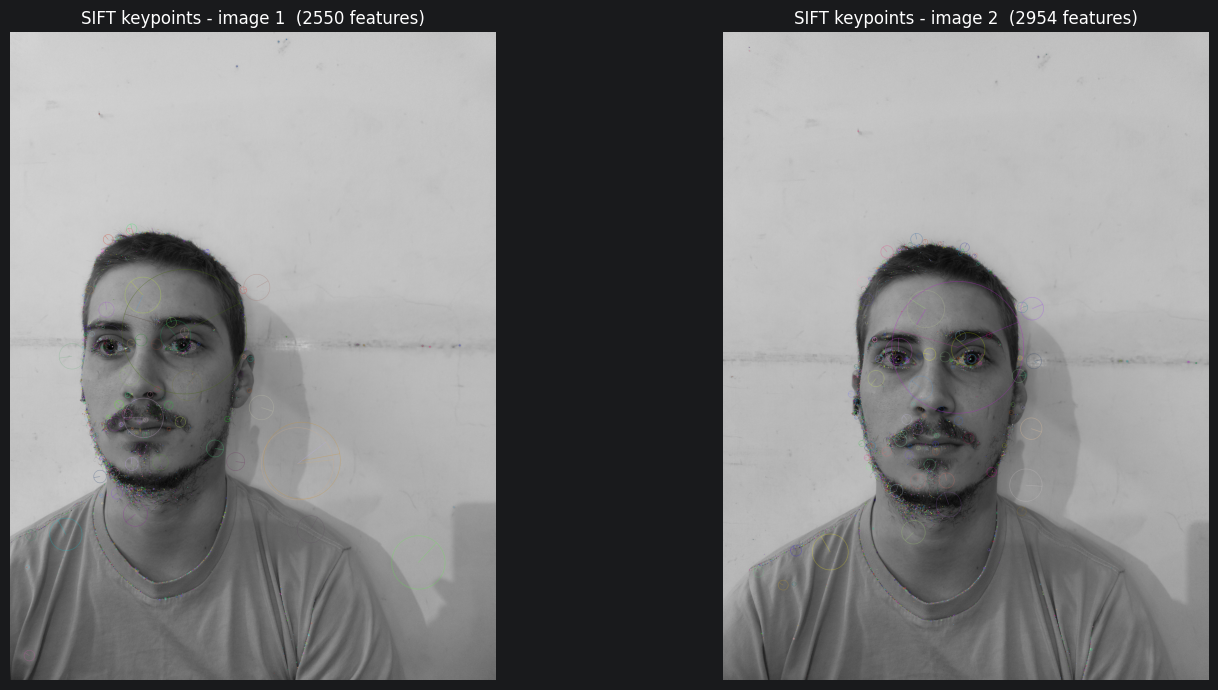

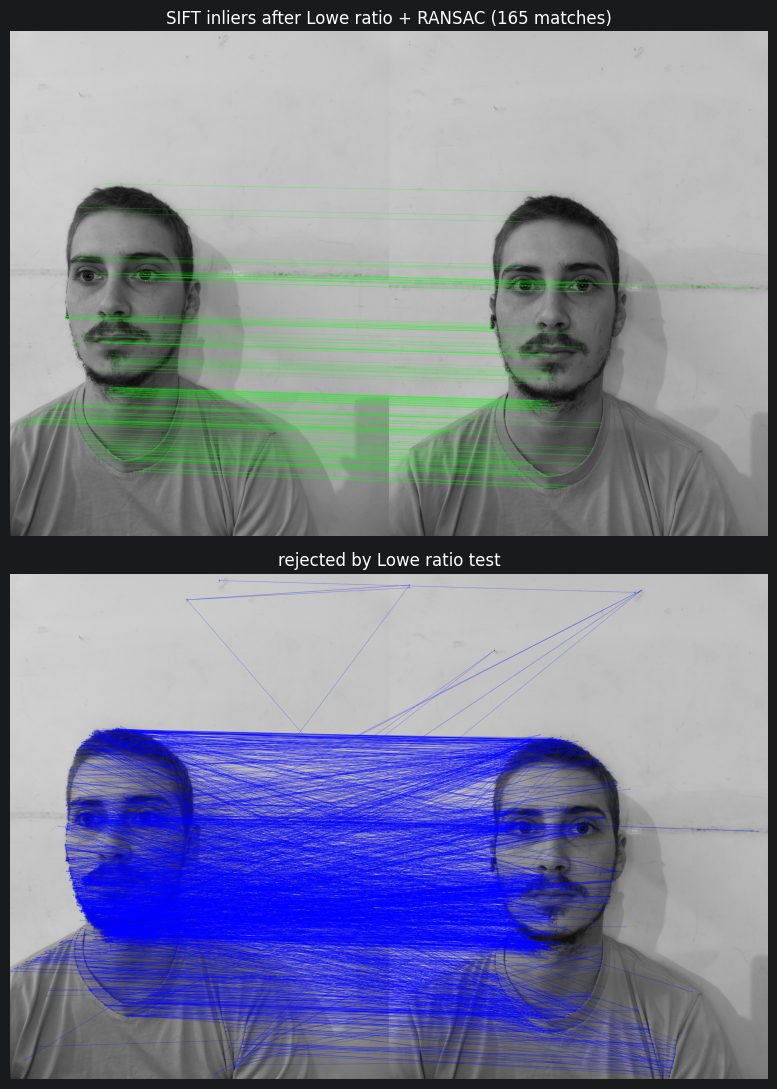

Representative keypoint scale: 3.38 px
Representative keypoint orientation: 49.04 deg
Features in image 1: 2550
Features in image 2: 2954
Raw KNN matches: 2550
After Lowe ratio (0.8): 277
After RANSAC: 165
Rejected by ratio test: 2273


In [9]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("hw3_report_figures")
OUTPUT_DIR.mkdir(exist_ok=True)


def compute_sift_correspondences(img1_path, img2_path, output_dir=OUTPUT_DIR, ratio=0.80, use_ransac=True):
    img1_gray = cv2.imread(str(img1_path), cv2.IMREAD_GRAYSCALE)
    img2_gray = cv2.imread(str(img2_path), cv2.IMREAD_GRAYSCALE)

    if img1_gray is None or img2_gray is None:
        raise FileNotFoundError("One or both feature-matching images were not found.")

    sift = cv2.SIFT_create()
    kp1, desc1 = sift.detectAndCompute(img1_gray, None)
    kp2, desc2 = sift.detectAndCompute(img2_gray, None)

    if desc1 is None or desc2 is None:
        raise RuntimeError("SIFT descriptors were not computed for both images.")

    # draw keypoints with scale and orientation
    kp1_img = cv2.drawKeypoints(
        img1_gray, kp1, None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    )
    kp2_img = cv2.drawKeypoints(
        img2_gray, kp2, None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    )
    kp1_path = output_dir / "sift_keypoints_img1.png"
    kp2_path = output_dir / "sift_keypoints_img2.png"
    cv2.imwrite(str(kp1_path), kp1_img)
    cv2.imwrite(str(kp2_path), kp2_img)

    fig_kp, ax_kp = plt.subplots(1, 2, figsize=(16, 7))
    ax_kp[0].imshow(cv2.cvtColor(kp1_img, cv2.COLOR_BGR2RGB))
    ax_kp[0].set_title(f"SIFT keypoints - image 1  ({len(kp1)} features)")
    ax_kp[0].axis("off")
    ax_kp[1].imshow(cv2.cvtColor(kp2_img, cv2.COLOR_BGR2RGB))
    ax_kp[1].set_title(f"SIFT keypoints - image 2  ({len(kp2)} features)")
    ax_kp[1].axis("off")
    fig_kp.tight_layout()
    kp_combined_path = output_dir / "sift_keypoints_only.png"
    fig_kp.savefig(str(kp_combined_path), dpi=200, bbox_inches="tight")
    plt.show()

    # match descriptors using brute force knn, then apply Lowe ratio test
    matcher = cv2.BFMatcher(cv2.NORM_L2)
    raw_matches = matcher.knnMatch(desc1, desc2, k=2)

    good_matches, rejected_matches = [], []
    for match_pair in raw_matches:
        if len(match_pair) < 2:
            continue
        m, n = match_pair
        if m.distance < ratio * n.distance:
            good_matches.append(m)
        else:
            rejected_matches.append([m])

    # use fundamental matrix RANSAC to filter out remaining outliers
    ransac_matches = good_matches
    if use_ransac and len(good_matches) >= 8:
        pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches])
        pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches])
        _, mask = cv2.findFundamentalMat(
            pts1, pts2,
            method=cv2.FM_RANSAC,
            ransacReprojThreshold=3.0,
            confidence=0.99,
        )
        if mask is not None:
            ransac_matches = [good_matches[i] for i, keep in enumerate(mask.ravel()) if keep]

    ransac_draw = [[m] for m in ransac_matches]

    # green = inliers after RANSAC, red = rejected by ratio test
    inlier_img = cv2.drawMatchesKnn(
        img1_gray, kp1, img2_gray, kp2, ransac_draw, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
        matchColor=(0, 255, 0),
    )
    outlier_img = cv2.drawMatchesKnn(
        img1_gray, kp1, img2_gray, kp2, rejected_matches, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
        matchColor=(255, 0, 0),
    )

    inlier_path = output_dir / "sift_inlier_cross_references.png"
    outlier_path = output_dir / "sift_rejected_cross_references.png"
    combined_path = output_dir / "sift_match_summary.png"

    cv2.imwrite(str(inlier_path), inlier_img)
    cv2.imwrite(str(outlier_path), outlier_img)

    fig, ax = plt.subplots(2, 1, figsize=(14, 11))
    ax[0].imshow(cv2.cvtColor(inlier_img, cv2.COLOR_BGR2RGB))
    suffix = " + RANSAC" if use_ransac else ""
    ax[0].set_title(f"SIFT inliers after Lowe ratio{suffix} ({len(ransac_matches)} matches)")
    ax[0].axis("off")
    ax[1].imshow(cv2.cvtColor(outlier_img, cv2.COLOR_BGR2RGB))
    ax[1].set_title("rejected by Lowe ratio test")
    ax[1].axis("off")
    fig.tight_layout()
    fig.savefig(combined_path, dpi=200, bbox_inches="tight")
    plt.show()

    if kp1:
        print(f"Representative keypoint scale: {kp1[0].size:.2f} px")
        print(f"Representative keypoint orientation: {kp1[0].angle:.2f} deg")

    print(f"Features in image 1: {len(kp1)}")
    print(f"Features in image 2: {len(kp2)}")
    print(f"Raw KNN matches: {len(raw_matches)}")
    print(f"After Lowe ratio ({ratio}): {len(good_matches)}")
    if use_ransac:
        print(f"After RANSAC: {len(ransac_matches)}")
    print(f"Rejected by ratio test: {len(rejected_matches)}")

    return {
        "keypoints_1": len(kp1),
        "keypoints_2": len(kp2),
        "raw_matches": len(raw_matches),
        "ratio_matches": len(good_matches),
        "ransac_matches": len(ransac_matches),
        "rejected_matches": len(rejected_matches),
    }


sift_stats = compute_sift_correspondences("images/image11.jpg", "images/image12.jpg", ratio=0.8, use_ransac=True)
